# Кейс 2. Аудит атрибуции: MMP против внутренней базы

**Вопрос:** маркетинг видит в MMP одни цифры регистраций и покупок, база показывает другие. Надо понять, насколько MMP покрывает реальных пользователей, откуда расхождения и что поправить в выгрузке и SDK.

**Период:** август 2026.

**Источники:**
- `users`, `orders`: внутренняя база, время в UTC+5;
- `mmp_events_nonorganic`, `mmp_events_organic`: выгрузка сырых событий из MMP, время в UTC. Отчёт по органике сначала не выгрузили.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import pf

pf.setup_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
con = pf.connect()
q = pf.Q(con, "queries.sql")

## 1. Первая сверка "в лоб"

Берём август по календарю каждой системы и неорганический отчёт MMP, как его прислали.

In [2]:
naive = q("naive_compare")
naive

,event_name,db_cnt,mmp_cnt,mmp_to_db
0,af_complete_registration,4131,3331,0.806
1,af_purchase,3454,2758,0.798


Регистраций в MMP заметно меньше, чем в базе, покупок тоже меньше. Разбираем по шагам. Сначала собираем единую таблицу событий MMP: оба отчёта, id пользователя очищен от пробелов и ведущих нулей, время переведено в UTC+5, повторные события помечены.

In [3]:
con.execute(f"CREATE OR REPLACE TEMP TABLE mmp AS {q.queries['mmp_clean']}")
con.sql("SELECT report, event_name, COUNT(*) AS events FROM mmp GROUP BY ALL ORDER BY ALL").df()

,report,event_name,events
0,nonorganic,af_complete_registration,3536
1,nonorganic,af_purchase,2937
2,organic,af_complete_registration,781
3,organic,af_purchase,919


## 2. Покрытие по id пользователя

Главная метрика аудита: какая доля пользователей базы вообще есть в MMP. Считаем тремя способами: как сделали сначала (неорганический отчёт, матч строкой), с очисткой id, и с добавленным органическим отчётом.

In [4]:
cov = q("coverage_by_user")
cov["media_source"] = cov["media_source"].fillna("итого")
cov

,media_source,db_users,cov_nonorganic_raw,cov_nonorganic_clean,cov_both_reports
0,google,978,0.964,0.975,0.975
1,meta,826,0.960,0.975,0.975
2,organic,752,0.000,0.000,0.965
3,tiktok,1284,0.960,0.978,0.978
4,yandex,291,0.945,0.959,0.959
5,итого,4131,0.785,0.797,0.973


In [5]:
idq = q("id_quality")
idq

,id_format,events,share
0,корректный,7954,0.973
1,пустой (событие до логина),100,0.012
2,ведущие нули,72,0.009
3,пробел в конце,47,0.006


In [6]:
cv = cov.set_index("media_source")
idq_i = idq.set_index("id_format")
paid_cov = cv.loc[["google", "meta", "tiktok", "yandex"], "cov_both_reports"]
print(f"Без id: {idq_i.loc['пустой (событие до логина)', 'share']:.1%} событий (события до логина)")
print(f"Ведущие нули или пробел: {idq_i.loc[['ведущие нули', 'пробел в конце'], 'share'].sum():.1%} событий, строковый матч их теряет")
print(f"Покрытие платных каналов после очистки: {paid_cov.min():.1%} - {paid_cov.max():.1%}")
print(f"Органика без органического отчёта: {cv.loc['organic', 'cov_nonorganic_clean']:.0%}, с ним: {cv.loc['organic', 'cov_both_reports']:.1%}")

Без id: 1.2% событий (события до логина)
Ведущие нули или пробел: 1.5% событий, строковый матч их теряет
Покрытие платных каналов после очистки: 95.9% - 97.8%
Органика без органического отчёта: 0%, с ним: 96.5%


Часть событий приходит без id (до логина), часть id записана с ведущими нулями или пробелом, и строковый матч их теряет. Без органического отчёта из сверки выпадает вся органика.

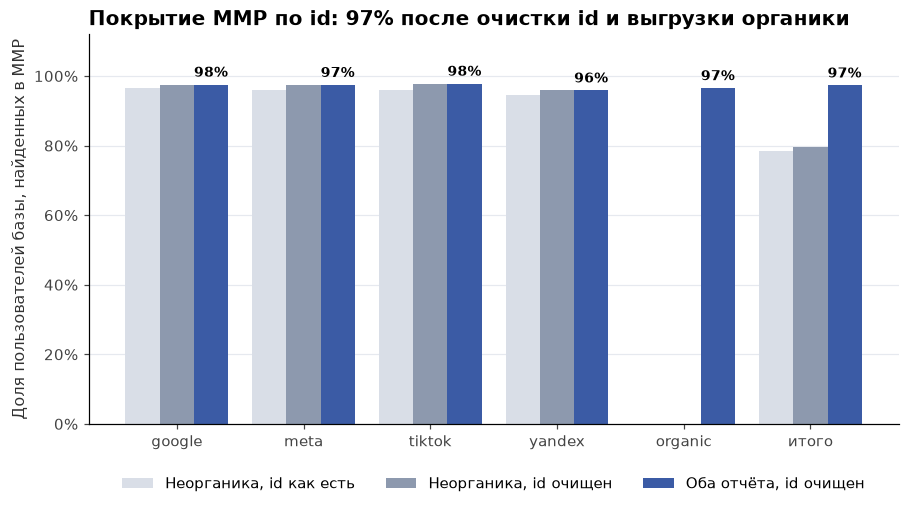

In [7]:
c = cov.set_index("media_source")
order = ["google", "meta", "tiktok", "yandex", "organic", "итого"]
c = c.loc[order]
fig, ax = plt.subplots(figsize=(9.5, 4.6))
x = np.arange(len(c))
w = 0.27
cols = [("cov_nonorganic_raw", "Неорганика, id как есть", pf.COLORS["light"]),
        ("cov_nonorganic_clean", "Неорганика, id очищен", pf.COLORS["muted"]),
        ("cov_both_reports", "Оба отчёта, id очищен", pf.COLORS["main"])]
for i, (col, label, color) in enumerate(cols):
    b = ax.bar(x + (i - 1) * w, c[col], w, color=color, label=label)
    if col == "cov_both_reports":
        ax.bar_label(b, labels=[f"{v:.0%}" for v in c[col]], padding=3, fontsize=9, fontweight="bold")
ax.set_xticks(x, c.index)
pf.pct_axis(ax)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Доля пользователей базы, найденных в MMP")
ax.set_title(f"Покрытие MMP по id: {c.loc['итого', 'cov_both_reports']:.0%} после очистки id и выгрузки органики")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
pf.save(fig, "01_coverage_by_user")
plt.show()

## 3. Часовой пояс

MMP отдаёт UTC, база пишет Алматы (UTC+5). Событие в 02:00 по Алматы попадает в MMP в предыдущий день, а 1 сентября с 00:00 до 05:00 по местному времени MMP относит к августу.

In [8]:
tz = q("timezone_shift")
tz

,event_name,aug_by_utc,aug_by_local,day_changes,total
0,af_complete_registration,4062,4054,216,4317
1,af_purchase,3606,3606,182,3856


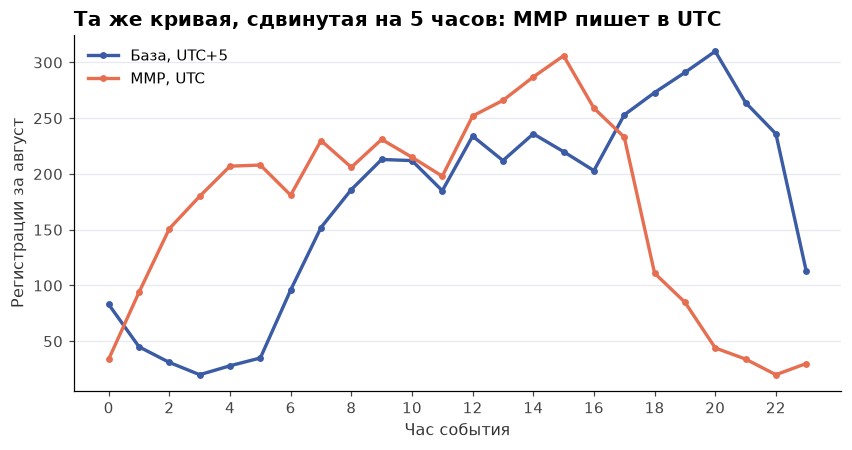

In [9]:
hs = q("hourly_shift").pivot(index="hour", columns="source", values="n")
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(hs.index, hs["База (UTC+5)"], color=pf.COLORS["main"], lw=2.2, marker="o", ms=3.5, label="База, UTC+5")
ax.plot(hs.index, hs["MMP (UTC)"], color=pf.COLORS["accent"], lw=2.2, marker="o", ms=3.5, label="MMP, UTC")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Час события")
ax.set_ylabel("Регистрации за август")
ax.set_title("Та же кривая, сдвинутая на 5 часов: MMP пишет в UTC")
ax.legend()
pf.save(fig, "02_hourly_shift")
plt.show()

За месяц в целом сдвиг почти не виден: сколько событий уходит в соседний месяц в начале, столько приходит в конце. Зато дневные цифры расходятся заметно.

In [10]:
dt = q("daily_tz_error")
mae_utc, mae_local = dt["err_utc"].abs().mean(), dt["err_local"].abs().mean()
print(f"Средняя абсолютная ошибка по дням: по дате UTC {mae_utc:.1%}, по дате UTC+5 {mae_local:.1%}")
dt.head(7)

Средняя абсолютная ошибка по дням: по дате UTC 3.1%, по дате UTC+5 1.9%


,day,db_cnt,mmp_utc,mmp_local,err_utc,err_local
0,2026-08-01,128,128,124,0.000,-0.031
1,2026-08-02,140,133,136,-0.050,-0.029
2,2026-08-03,135,138,133,0.022,-0.015
3,2026-08-04,111,100,105,-0.099,-0.054
4,2026-08-05,120,123,120,0.025,0.000
5,2026-08-06,118,117,117,-0.008,-0.008
6,2026-08-07,118,119,117,0.008,-0.008


## 4. Покупки: событие к заказу

Матчим af_purchase с заказами базы по order_id и сумме: order_id повторяется между каналами (см. кейс 5), сумма разводит совпадения.

In [11]:
pm = q("purchase_match")
pm

,os,db_orders,matched,match_rate,mmp_events_raw,mmp_duplicates,raw_to_db
0,ios,1766,1713,0.970,1713,0,0.970
1,android,1688,1688,1.000,1893,205,1.121


На Android событий покупки больше, чем заказов: SDK отправляет часть событий повторно через несколько секунд. На iOS наоборот, часть заказов не доходит до MMP. В сумме по двум ОС ошибки частично гасят друг друга, поэтому общий итог выглядит почти нормально, а по ОС расходится.

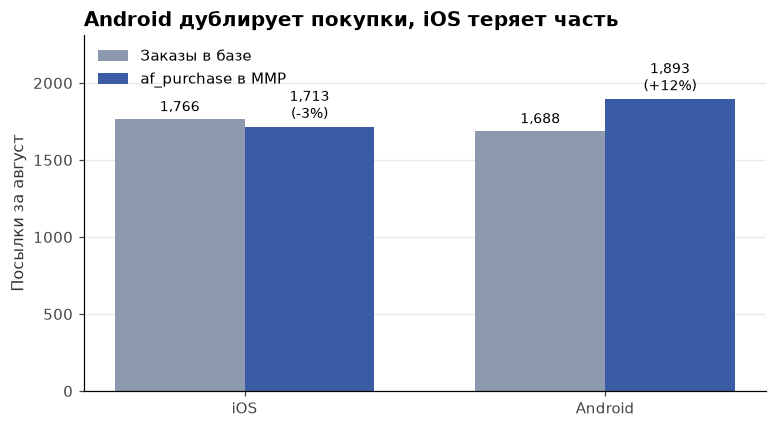

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(pm))
w = 0.36
b1 = ax.bar(x - w / 2, pm["db_orders"], w, color=pf.COLORS["muted"], label="Заказы в базе")
b2 = ax.bar(x + w / 2, pm["mmp_events_raw"], w, color=pf.COLORS["main"], label="af_purchase в MMP")
ax.bar_label(b1, labels=[f"{v:,.0f}" for v in pm["db_orders"]], padding=3, fontsize=9)
ax.bar_label(b2, labels=[f"{v:,.0f}\n({r - 1:+.0%})" for v, r in zip(pm["mmp_events_raw"], pm["raw_to_db"])], padding=3, fontsize=9)
ax.set_xticks(x, ["iOS", "Android"])
ax.set_ylim(0, pm[["db_orders", "mmp_events_raw"]].values.max() * 1.22)
ax.set_ylabel("Посылки за август")
ax.set_title("Android дублирует покупки, iOS теряет часть")
ax.legend(loc="upper left")
pf.save(fig, "03_purchases_by_os")
plt.show()

## 5. Гео: страна по IP

MMP определяет страну по IP в момент события. Пользователь из Узбекистана, который регистрируется в поездке или через VPN, в MMP попадает в Турцию или Германию. Берём только пользователей, найденных в обеих системах, чтобы отделить гео от покрытия.

In [13]:
geo = q("geo_compare")
geo

,country,users_matched,mmp_same_country,mmp_country_gap,other_countries
0,KZ,3209,3175,-0.011,"AE, DE, PL, RU, TR"
1,UZ,480,425,-0.115,"AE, DE, PL, RU, TR"
2,KG,317,290,-0.085,"AE, DE, PL, RU, TR"


In [14]:
q("geo_by_ip_country")

,country_db,country_ip,users
0,KG,TR,13
1,KG,RU,6
2,KG,AE,3
3,KG,PL,3
4,KG,DE,2
5,KZ,TR,11
6,KZ,PL,9
7,KZ,DE,5
8,KZ,RU,5
9,KZ,AE,4


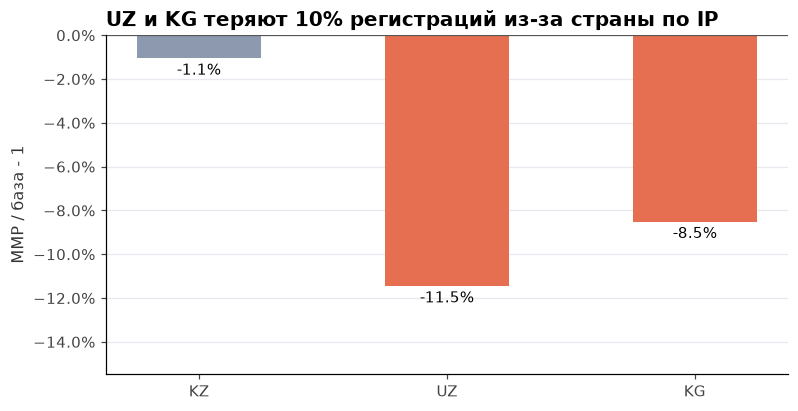

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
g = geo.set_index("country").loc[["KZ", "UZ", "KG"]]
bars = ax.bar(g.index, g["mmp_country_gap"], color=[pf.COLORS["muted"], pf.COLORS["accent"], pf.COLORS["accent"]], width=0.5)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in g["mmp_country_gap"]], padding=3)
pf.pct_axis(ax)
ax.set_ylim(g["mmp_country_gap"].min() * 1.35, 0)
ax.axhline(0, color="#555555", lw=0.8)
ax.set_ylabel("MMP / база - 1")
ax.set_title(f"UZ и KG теряют {-g.loc[['UZ', 'KG'], 'mmp_country_gap'].mean():.0%} регистраций из-за страны по IP")
pf.save(fig, "04_geo_gap")
plt.show()

In [16]:
q("coverage_by_country")

,country,db_users,coverage_by_id
0,KZ,3317,0.971
1,UZ,493,0.974
2,KG,321,0.991


По id пользователя покрытие в UZ и KG такое же, как в KZ. Значит, отчёт MMP по странам нельзя использовать для оценки гео-кампаний: страну надо брать из базы через id.

## 6. Итоговая сверка: откуда расхождение

In [17]:
fin = q("final_compare").set_index("event_name")
fin

,db_cnt,step0_nonorganic_utc,step1_plus_organic,step2_local_time,step3_no_duplicates
event_name,,,,,
af_complete_registration,4131,3331,4062,4054,4054
af_purchase,3454,2758,3606,3606,3401


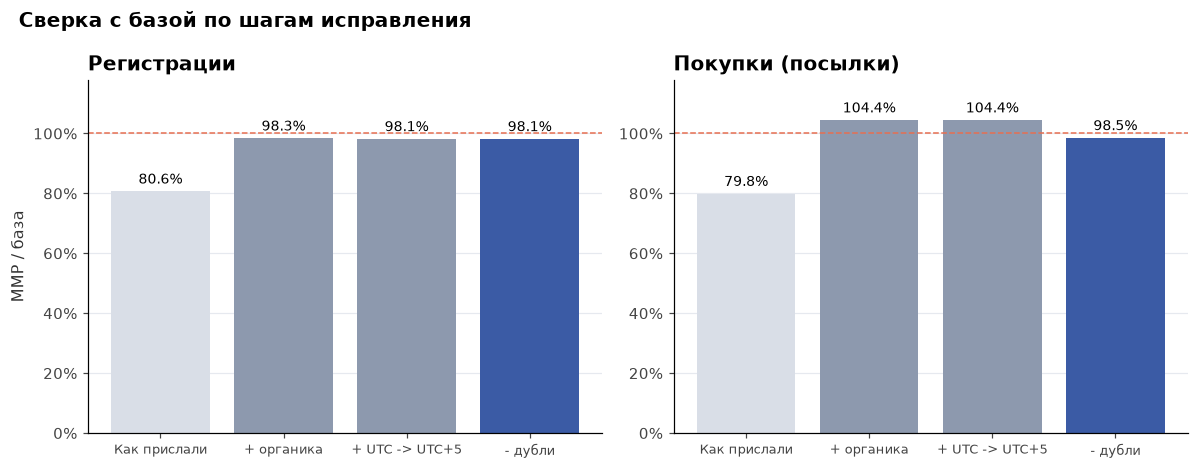

In [18]:
steps = ["step0_nonorganic_utc", "step1_plus_organic", "step2_local_time", "step3_no_duplicates"]
labels = ["Как прислали", "+ органика", "+ UTC -> UTC+5", "- дубли"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, ev, title in zip(axes, ["af_complete_registration", "af_purchase"], ["Регистрации", "Покупки (посылки)"]):
    r = fin.loc[ev]
    vals = [r[s] / r["db_cnt"] for s in steps]
    bars = ax.bar(labels, vals, color=[pf.COLORS["light"], pf.COLORS["muted"], pf.COLORS["muted"], pf.COLORS["main"]])
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in vals], padding=3, fontsize=9)
    ax.axhline(1, color=pf.COLORS["accent"], lw=1, ls="--")
    pf.pct_axis(ax)
    ax.set_ylim(0, 1.18)
    ax.set_title(title)
    ax.tick_params(axis="x", labelsize=8.5)
axes[0].set_ylabel("MMP / база")
fig.suptitle("Сверка с базой по шагам исправления", x=0.02, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
pf.save(fig, "05_reconciliation_steps")
plt.show()

## 7. Причины расхождений

In [19]:
pm_i = pm.set_index("os")
g_i = geo.set_index("country")
causes = pd.DataFrame([
    ("Не выгружен отчёт по органике", "В MMP нет органических пользователей",
     f"покрытие по id {cv.loc['итого', 'cov_nonorganic_clean']:.0%} -> {cv.loc['итого', 'cov_both_reports']:.0%}"),
    ("UTC против UTC+5", "События с 00:00 до 05:00 по Алматы уходят в предыдущий день",
     f"{tz['day_changes'].sum() / tz['total'].sum():.1%} событий меняют дату, дневная ошибка {mae_utc:.1%} -> {mae_local:.1%}"),
    ("Формат customer_user_id", "Пустой id до логина, ведущие нули, пробелы",
     f"{idq_i.loc[idq_i.index != 'корректный', 'share'].sum():.1%} событий не матчатся строкой"),
    ("Повторная отправка на Android", "Одна покупка приходит дважды с разницей в секунды",
     f"Android завышен на {pm_i.loc['android', 'raw_to_db'] - 1:.0%}"),
    ("Потери на iOS", "Часть покупок не доходит до MMP",
     f"iOS занижен на {1 - pm_i.loc['ios', 'raw_to_db']:.0%}"),
    ("Страна по IP", "Поездки и VPN",
     f"UZ {g_i.loc['UZ', 'mmp_country_gap']:.0%}, KG {g_i.loc['KG', 'mmp_country_gap']:.0%} в отчёте по странам"),
], columns=["Причина", "Что видно", "Влияние, август"])
causes.style.hide(axis="index")

Причина,Что видно,"Влияние, август"
Не выгружен отчёт по органике,В MMP нет органических пользователей,покрытие по id 80% -> 97%
UTC против UTC+5,События с 00:00 до 05:00 по Алматы уходят в предыдущий день,"4.9% событий меняют дату, дневная ошибка 3.1% -> 1.9%"
Формат customer_user_id,"Пустой id до логина, ведущие нули, пробелы",2.7% событий не матчатся строкой
Повторная отправка на Android,Одна покупка приходит дважды с разницей в секунды,Android завышен на 12%
Потери на iOS,Часть покупок не доходит до MMP,iOS занижен на 3%
Страна по IP,Поездки и VPN,"UZ -11%, KG -9% в отчёте по странам"


## 8. Чек-лист для разработчиков

1. Вызывать `setCustomerUserId` до первого события, сразу после логина или регистрации. Сейчас часть событий уходит без id.
2. Передавать id строкой из цифр без ведущих нулей и пробелов, тот же формат, что в базе.
3. На Android добавить идентификатор события (order_id) и не отправлять повторно событие с уже отправленным order_id.
4. На iOS проверить, что af_purchase отправляется после подтверждения заказа, а не при закрытии экрана.
5. В af_purchase передавать order_id и сумму: без них сверку по заказам не сделать.
6. В выгрузке для аналитики брать оба отчёта (неорганика и органика) и фиксировать часовой пояс UTC+5 в параметрах запроса.
7. Страну для отчётов брать из базы по id пользователя, а не из IP в MMP.

In [20]:
reg = fin.loc["af_complete_registration"]
pur = fin.loc["af_purchase"]
res = {
    "daily_mae_utc": mae_utc,
    "daily_mae_local": mae_local,
    "db_regs": reg["db_cnt"],
    "db_orders": pur["db_cnt"],
    "naive_regs_ratio": reg["step0_nonorganic_utc"] / reg["db_cnt"],
    "naive_purchases_ratio": pur["step0_nonorganic_utc"] / pur["db_cnt"],
    "final_regs_ratio": reg["step3_no_duplicates"] / reg["db_cnt"],
    "final_purchases_ratio": pur["step3_no_duplicates"] / pur["db_cnt"],
    "cov_total_raw": cv.loc["итого", "cov_nonorganic_raw"],
    "cov_total_clean_nonorganic": cv.loc["итого", "cov_nonorganic_clean"],
    "cov_total_both": cv.loc["итого", "cov_both_reports"],
    "cov_paid_min": cv.loc[["google", "meta", "tiktok", "yandex"], "cov_both_reports"].min(),
    "cov_paid_max": cv.loc[["google", "meta", "tiktok", "yandex"], "cov_both_reports"].max(),
    "tz_day_change_share": tz["day_changes"].sum() / tz["total"].sum(),
    "id_empty_share": idq_i.loc["пустой (событие до логина)", "share"],
    "id_bad_format_share": idq_i.loc[["ведущие нули", "пробел в конце"], "share"].sum(),
    "android_raw_to_db": pm_i.loc["android", "raw_to_db"],
    "ios_raw_to_db": pm_i.loc["ios", "raw_to_db"],
    "android_match": pm_i.loc["android", "match_rate"],
    "ios_match": pm_i.loc["ios", "match_rate"],
    "geo_gap_kz": g_i.loc["KZ", "mmp_country_gap"],
    "geo_gap_uz": g_i.loc["UZ", "mmp_country_gap"],
    "geo_gap_kg": g_i.loc["KG", "mmp_country_gap"],
}
pf.save_results(res)
pd.Series(res)

daily_mae_utc                    0.031
daily_mae_local                  0.019
db_regs                      4,131.000
db_orders                    3,454.000
naive_regs_ratio                 0.806
naive_purchases_ratio            0.798
final_regs_ratio                 0.981
final_purchases_ratio            0.985
cov_total_raw                    0.785
cov_total_clean_nonorganic       0.797
cov_total_both                   0.973
cov_paid_min                     0.959
cov_paid_max                     0.978
tz_day_change_share              0.049
id_empty_share                   0.012
id_bad_format_share              0.015
android_raw_to_db                1.121
ios_raw_to_db                    0.970
android_match                    1.000
ios_match                        0.970
geo_gap_kz                      -0.011
geo_gap_uz                      -0.115
geo_gap_kg                      -0.085
dtype: float64